In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

Assembling system matrix...
Solving system...
Extracting displacement fields...
Computing strain fields...
Computing stress fields...


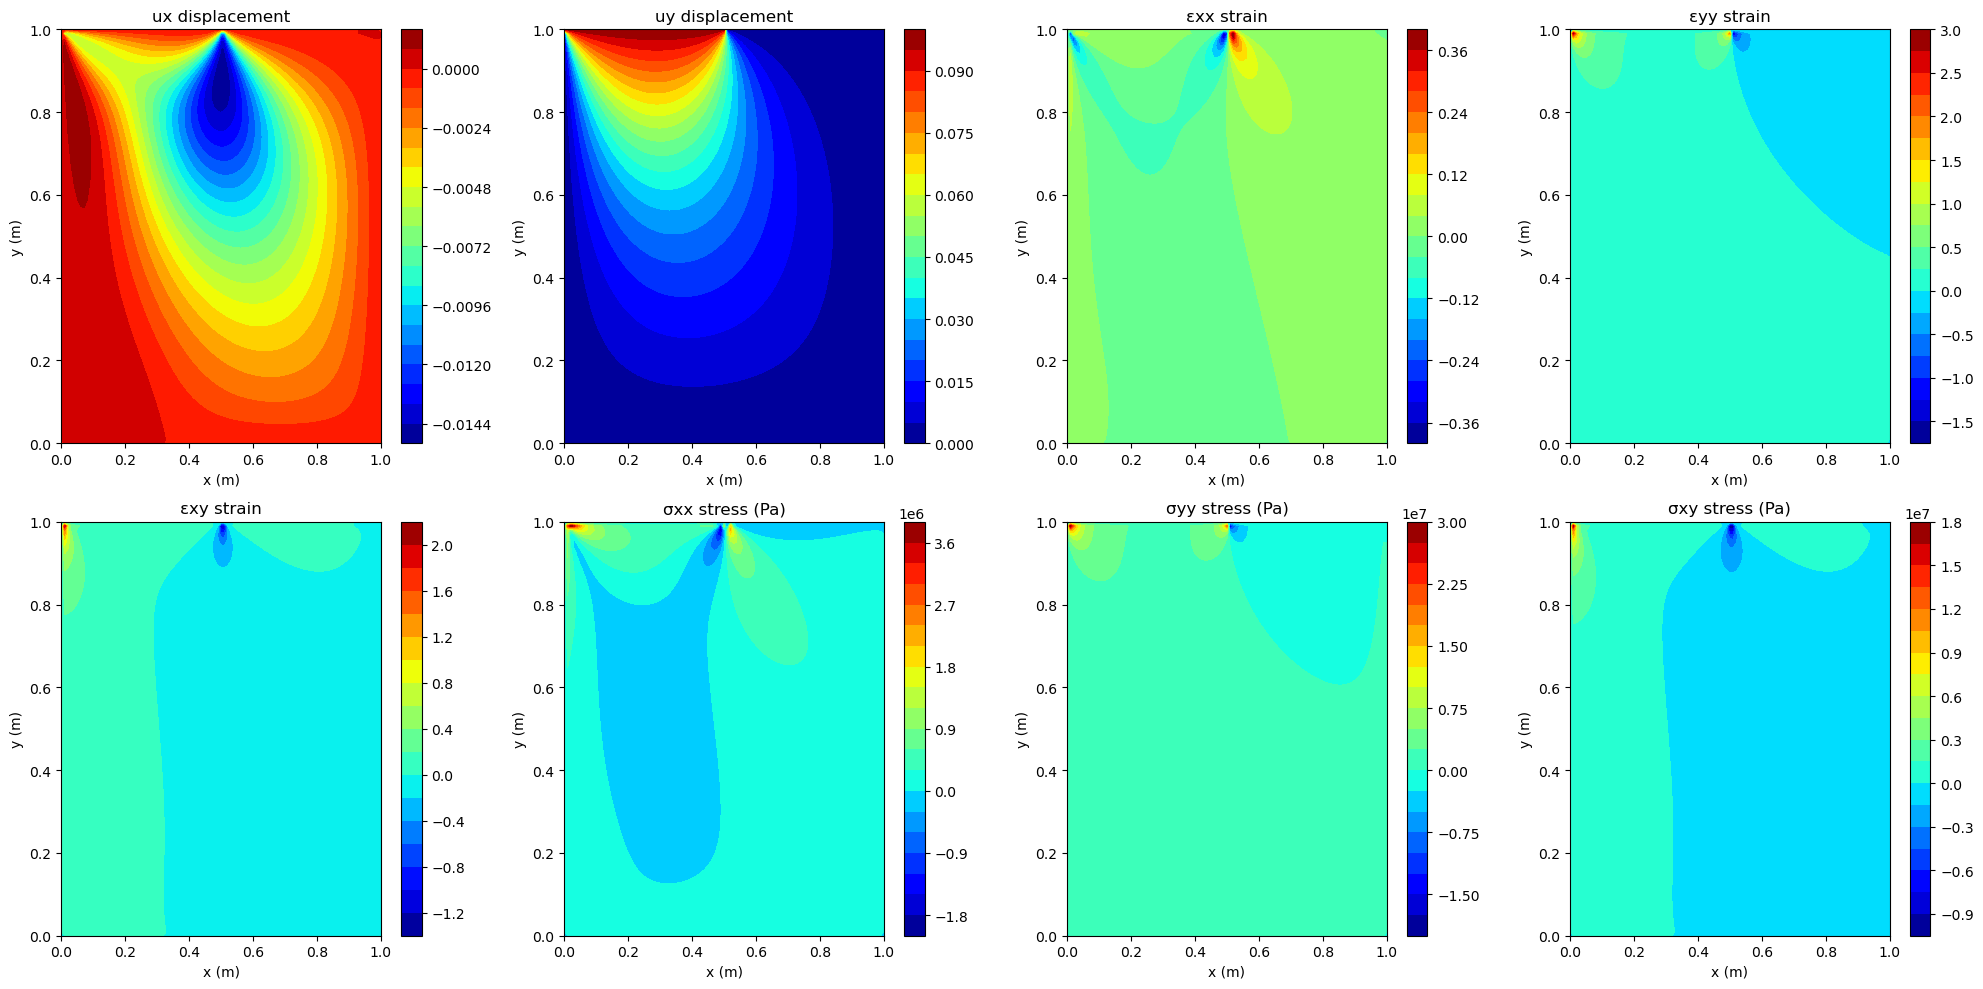


=== Solution Summary ===
ux range: [-1.504059e-02, 1.341794e-03] m
uy range: [0.000000e+00, 1.000000e-01] m
εxx range: [-3.961541e-01, 3.983190e-01]
εyy range: [-1.738636e+00, 2.896143e+00]
εxy range: [-1.242681e+00, 2.014120e+00]
σxx range: [-1.876790e+06, 3.822718e+06] Pa
σyy range: [-1.751786e+07, 2.950726e+07] Pa
σxy range: [-1.035568e+07, 1.678433e+07] Pa


In [5]:
# Problem parameters
E = 10e6  # Elastic modulus (Pa)
nu = 0.2  # Poisson's ratio
Lx, Ly = 1.0, 1.0  # Domain size (m)

# Discretization
nx, ny = 101, 101  # Grid points
dx = Lx / (nx - 1)
dy = Ly / (ny - 1)

# Create coordinate arrays
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

# Total degrees of freedom
ndof = 2 * nx * ny

# Function to map (i, j, direction) to global DOF index
def get_dof(i, j, direction):
    """
    direction: 0 for ux, 1 for uy
    Returns global DOF index
    """
    node = i * ny + j
    return 2 * node + direction

# Initialize sparse matrix and RHS vector
K = lil_matrix((ndof, ndof))
F = np.zeros(ndof)

# Plane stress constitutive matrix
D = (E / (1 - nu**2)) * np.array([
    [1, nu, 0],
    [nu, 1, 0],
    [0, 0, (1 - nu) / 2]
])

print("Assembling system matrix...")

# Assemble stiffness matrix using finite differences
# Using equilibrium equations: div(sigma) = 0
# For plane stress:
# σ_xx = E/(1-ν²) * (ε_xx + ν*ε_yy)
# σ_yy = E/(1-ν²) * (ε_yy + ν*ε_xx)
# σ_xy = E/(2(1+ν)) * γ_xy = G * γ_xy

G = E / (2 * (1 + nu))  # Shear modulus

# Equilibrium equations in terms of displacements:
# ∂σ_xx/∂x + ∂σ_xy/∂y = 0
# ∂σ_xy/∂x + ∂σ_yy/∂y = 0

# Expanded form:
# E/(1-ν²) * (∂²ux/∂x² + ν*∂²uy/∂x∂y) + G*(∂²ux/∂y² + ∂²uy/∂x∂y) = 0
# G*(∂²ux/∂x∂y + ∂²uy/∂x²) + E/(1-ν²)*(∂²uy/∂y² + ν*∂²ux/∂x∂y) = 0

a1 = E / (1 - nu**2)
a2 = G

for i in range(nx):
    for j in range(ny):
        dof_ux = get_dof(i, j, 0)
        dof_uy = get_dof(i, j, 1)
        
        # Check boundary conditions
        # Bottom boundary: y = 0
        if j == 0:
            K[dof_ux, dof_ux] = 1.0
            K[dof_uy, dof_uy] = 1.0
            F[dof_ux] = 0.0
            F[dof_uy] = 0.0
            continue
        
        # Top boundary with prescribed displacement
        if j == ny - 1 and i <= nx // 2:
            K[dof_ux, dof_ux] = 1.0
            K[dof_uy, dof_uy] = 1.0
            F[dof_ux] = 0.0
            F[dof_uy] = 0.1
            continue
        
        # Interior and traction-free boundary nodes
        # Use finite difference approximations
        
        # For ux equation
        if 0 < i < nx - 1 and 0 < j < ny - 1:
            # Interior point - full stencil
            # ∂²ux/∂x²
            K[dof_ux, get_dof(i+1, j, 0)] += a1 / dx**2
            K[dof_ux, get_dof(i-1, j, 0)] += a1 / dx**2
            K[dof_ux, dof_ux] += -2 * a1 / dx**2
            
            # ∂²ux/∂y²
            K[dof_ux, get_dof(i, j+1, 0)] += a2 / dy**2
            K[dof_ux, get_dof(i, j-1, 0)] += a2 / dy**2
            K[dof_ux, dof_ux] += -2 * a2 / dy**2
            
            # ∂²uy/∂x∂y (mixed derivative)
            K[dof_ux, get_dof(i+1, j+1, 1)] += (a1 * nu + a2) / (4 * dx * dy)
            K[dof_ux, get_dof(i+1, j-1, 1)] += -(a1 * nu + a2) / (4 * dx * dy)
            K[dof_ux, get_dof(i-1, j+1, 1)] += -(a1 * nu + a2) / (4 * dx * dy)
            K[dof_ux, get_dof(i-1, j-1, 1)] += (a1 * nu + a2) / (4 * dx * dy)
            
        elif i == 0 or i == nx - 1 or j == ny - 1:
            # Traction-free boundaries
            # Apply natural boundary conditions (zero traction)
            K[dof_ux, dof_ux] = 1.0
            F[dof_ux] = 0.0 if i == 0 or i == nx - 1 else (0.0 if i > nx // 2 else 0.0)
        
        # For uy equation
        if 0 < i < nx - 1 and 0 < j < ny - 1:
            # Interior point
            # ∂²uy/∂y²
            K[dof_uy, get_dof(i, j+1, 1)] += a1 / dy**2
            K[dof_uy, get_dof(i, j-1, 1)] += a1 / dy**2
            K[dof_uy, dof_uy] += -2 * a1 / dy**2
            
            # ∂²uy/∂x²
            K[dof_uy, get_dof(i+1, j, 1)] += a2 / dx**2
            K[dof_uy, get_dof(i-1, j, 1)] += a2 / dx**2
            K[dof_uy, dof_uy] += -2 * a2 / dx**2
            
            # ∂²ux/∂x∂y (mixed derivative)
            K[dof_uy, get_dof(i+1, j+1, 0)] += (a1 * nu + a2) / (4 * dx * dy)
            K[dof_uy, get_dof(i+1, j-1, 0)] += -(a1 * nu + a2) / (4 * dx * dy)
            K[dof_uy, get_dof(i-1, j+1, 0)] += -(a1 * nu + a2) / (4 * dx * dy)
            K[dof_uy, get_dof(i-1, j-1, 0)] += (a1 * nu + a2) / (4 * dx * dy)
            
        elif (i == 0 or i == nx - 1 or j == ny - 1) and not (j == ny - 1 and i <= nx // 2):
            # Traction-free boundaries (not already prescribed)
            K[dof_uy, dof_uy] = 1.0
            F[dof_uy] = 0.1 if (j == ny - 1 and i <= nx // 2) else 0.0

print("Solving system...")
# Convert to CSR format for efficient solving
K_csr = K.tocsr()

# Solve the system
U = spsolve(K_csr, F)

print("Extracting displacement fields...")
# Extract displacement fields
ux = np.zeros((nx, ny))
uy = np.zeros((nx, ny))

for i in range(nx):
    for j in range(ny):
        ux[i, j] = U[get_dof(i, j, 0)]
        uy[i, j] = U[get_dof(i, j, 1)]

# Transpose for proper orientation
ux = ux.T
uy = uy.T

print("Computing strain fields...")
# Compute strain fields
exx = np.zeros_like(ux)
eyy = np.zeros_like(uy)
exy = np.zeros_like(ux)

for i in range(1, nx - 1):
    for j in range(1, ny - 1):
        exx[j, i] = (ux[j, i+1] - ux[j, i-1]) / (2 * dx)
        eyy[j, i] = (uy[j+1, i] - uy[j-1, i]) / (2 * dy)
        exy[j, i] = 0.5 * ((ux[j+1, i] - ux[j-1, i]) / (2 * dy) + 
                           (uy[j, i+1] - uy[j, i-1]) / (2 * dx))

print("Computing stress fields...")
# Compute stress fields (plane stress)
sxx = (E / (1 - nu**2)) * (exx + nu * eyy)
syy = (E / (1 - nu**2)) * (eyy + nu * exx)
sxy = 2 * G * exy

# Plotting
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Displacement fields
im1 = axes[0, 0].contourf(X, Y, ux, levels=20, cmap='jet')
axes[0, 0].set_title('ux displacement')
axes[0, 0].set_xlabel('x (m)')
axes[0, 0].set_ylabel('y (m)')
plt.colorbar(im1, ax=axes[0, 0])

im2 = axes[0, 1].contourf(X, Y, uy, levels=20, cmap='jet')
axes[0, 1].set_title('uy displacement')
axes[0, 1].set_xlabel('x (m)')
axes[0, 1].set_ylabel('y (m)')
plt.colorbar(im2, ax=axes[0, 1])

# Strain fields
im3 = axes[0, 2].contourf(X, Y, exx, levels=20, cmap='jet')
axes[0, 2].set_title('εxx strain')
axes[0, 2].set_xlabel('x (m)')
axes[0, 2].set_ylabel('y (m)')
plt.colorbar(im3, ax=axes[0, 2])

im4 = axes[0, 3].contourf(X, Y, eyy, levels=20, cmap='jet')
axes[0, 3].set_title('εyy strain')
axes[0, 3].set_xlabel('x (m)')
axes[0, 3].set_ylabel('y (m)')
plt.colorbar(im4, ax=axes[0, 3])

im5 = axes[1, 0].contourf(X, Y, exy, levels=20, cmap='jet')
axes[1, 0].set_title('εxy strain')
axes[1, 0].set_xlabel('x (m)')
axes[1, 0].set_ylabel('y (m)')
plt.colorbar(im5, ax=axes[1, 0])

# Stress fields
im6 = axes[1, 1].contourf(X, Y, sxx, levels=20, cmap='jet')
axes[1, 1].set_title('σxx stress (Pa)')
axes[1, 1].set_xlabel('x (m)')
axes[1, 1].set_ylabel('y (m)')
plt.colorbar(im6, ax=axes[1, 1])

im7 = axes[1, 2].contourf(X, Y, syy, levels=20, cmap='jet')
axes[1, 2].set_title('σyy stress (Pa)')
axes[1, 2].set_xlabel('x (m)')
axes[1, 2].set_ylabel('y (m)')
plt.colorbar(im7, ax=axes[1, 2])

im8 = axes[1, 3].contourf(X, Y, sxy, levels=20, cmap='jet')
axes[1, 3].set_title('σxy stress (Pa)')
axes[1, 3].set_xlabel('x (m)')
axes[1, 3].set_ylabel('y (m)')
plt.colorbar(im8, ax=axes[1, 3])

plt.tight_layout()
plt.savefig('plane_stress_fdm_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n=== Solution Summary ===")
print(f"ux range: [{ux.min():.6e}, {ux.max():.6e}] m")
print(f"uy range: [{uy.min():.6e}, {uy.max():.6e}] m")
print(f"εxx range: [{exx.min():.6e}, {exx.max():.6e}]")
print(f"εyy range: [{eyy.min():.6e}, {eyy.max():.6e}]")
print(f"εxy range: [{exy.min():.6e}, {exy.max():.6e}]")
print(f"σxx range: [{sxx.min():.6e}, {sxx.max():.6e}] Pa")
print(f"σyy range: [{syy.min():.6e}, {syy.max():.6e}] Pa")
print(f"σxy range: [{sxy.min():.6e}, {sxy.max():.6e}] Pa")

In [6]:
# 将所有数据保存到一个CSV文件
print("\n保存数据到CSV文件...")

# 准备数据数组
# 我们将保存：x, y, ux, uy, exx, eyy, exy, sxx, syy, sxy
# 注意：X, Y, ux, uy, exx, eyy, exy, sxx, syy, sxy 都是(ny, nx)的形状
total_points = ny * nx
data = np.zeros((total_points, 10))

# 填充数据
index = 0
for i in range(ny):  # y方向
    for j in range(nx):  # x方向
        data[index, 0] = X[i, j]  # x坐标
        data[index, 1] = Y[i, j]  # y坐标
        data[index, 2] = ux[i, j]  # ux
        data[index, 3] = uy[i, j]  # uy
        data[index, 4] = exx[i, j]  # exx
        data[index, 5] = eyy[i, j]  # eyy
        data[index, 6] = exy[i, j]  # exy (张量剪应变)
        data[index, 7] = sxx[i, j]  # sxx
        data[index, 8] = syy[i, j]  # syy
        data[index, 9] = sxy[i, j]  # sxy
        index += 1

# 保存到CSV文件
filename = "results_p1-1_Claude.csv"
np.savetxt(
    filename, 
    data, 
    delimiter=',',
    fmt='%.6e',
    header='x,y,ux,uy,exx,eyy,exy,sxx,syy,sxy',
    comments=''
)

print(f"数据已保存到: {filename}")
print(f"数据形状: {data.shape}")
print(f"列: x, y, ux, uy, exx, eyy, exy, sxx, syy, sxy")
print("保存完成!")


保存数据到CSV文件...
数据已保存到: results_p1-1_Claude.csv
数据形状: (10201, 10)
列: x, y, ux, uy, exx, eyy, exy, sxx, syy, sxy
保存完成!
